Rows, Columns: (180519, 53)
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fnam

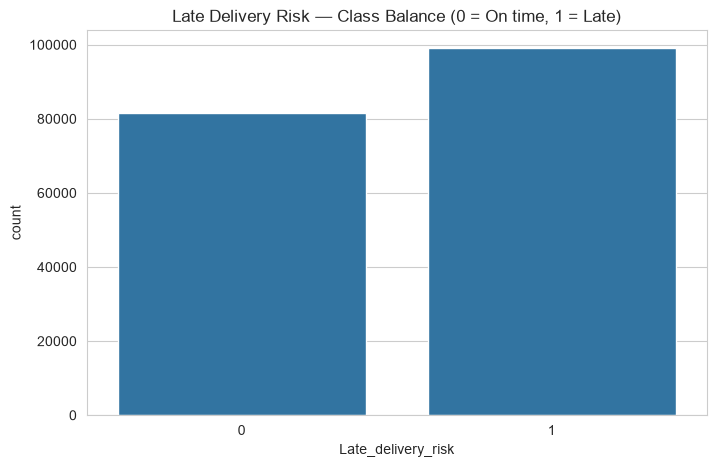

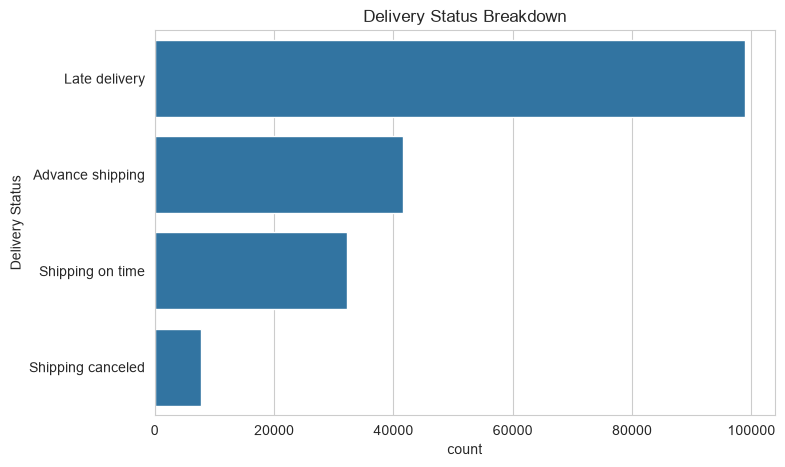

Dropped 24 columns. Remaining shape: (180519, 29)
Training data covers: 2015-01-01 00:00:00 to 2017-04-22 15:17:00
Test data covers:     2017-04-22 15:17:00 to 2018-01-31 23:38:00
Train rows: 144415  | Test rows: 36104


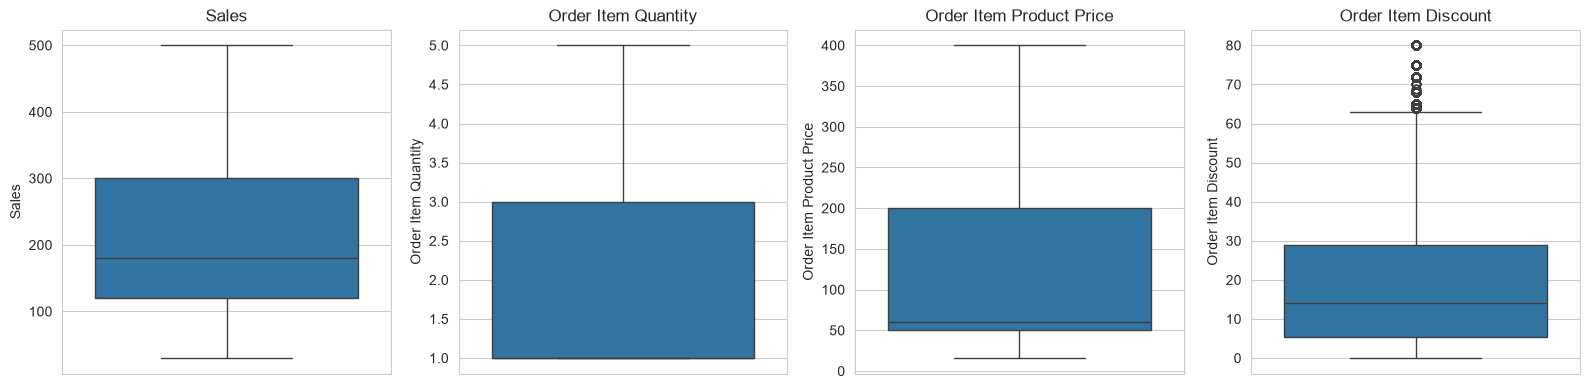

Train shape: (144415, 87) | Test shape: (36104, 87)
Dropping any leftover text columns: []
Final train shape: (144415, 87) | Final test shape: (36104, 87)
X_train: (144415, 86)  | X_test: (36104, 86)

Train target balance:
 Late_delivery_risk
1    0.548724
0    0.451276
Name: proportion, dtype: float64

Test target balance:
 Late_delivery_risk
1    0.54656
0    0.45344
Name: proportion, dtype: float64
MODEL PERFORMANCE COMPARISON
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.6896     0.8303  0.5432  0.6567   0.7427
Random Forest          0.7083     0.8462  0.5698  0.6810   0.7711
XGBoost                0.7013     0.8018  0.6023  0.6879   0.7703

MODEL PERFORMANCE (%)
                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     68.96      83.03   54.32  65.67    74.27
Random Forest           70.83      84.62   56.98  68.10    77.11
XGBoost                 70.13      80.18   60.23  68.79    77.03


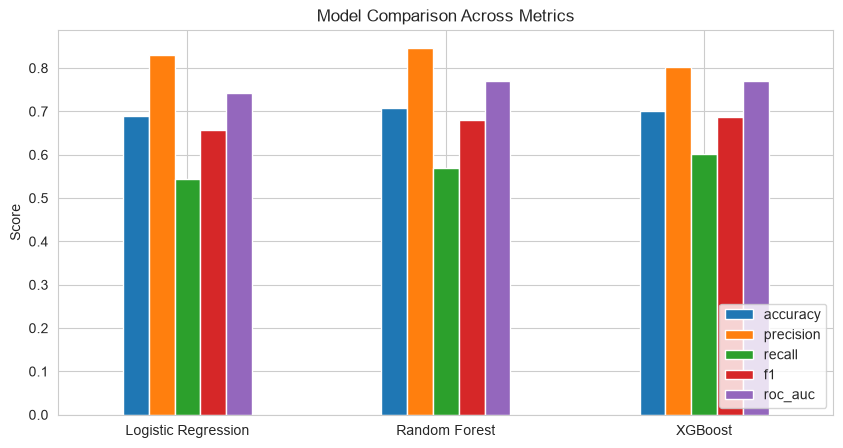

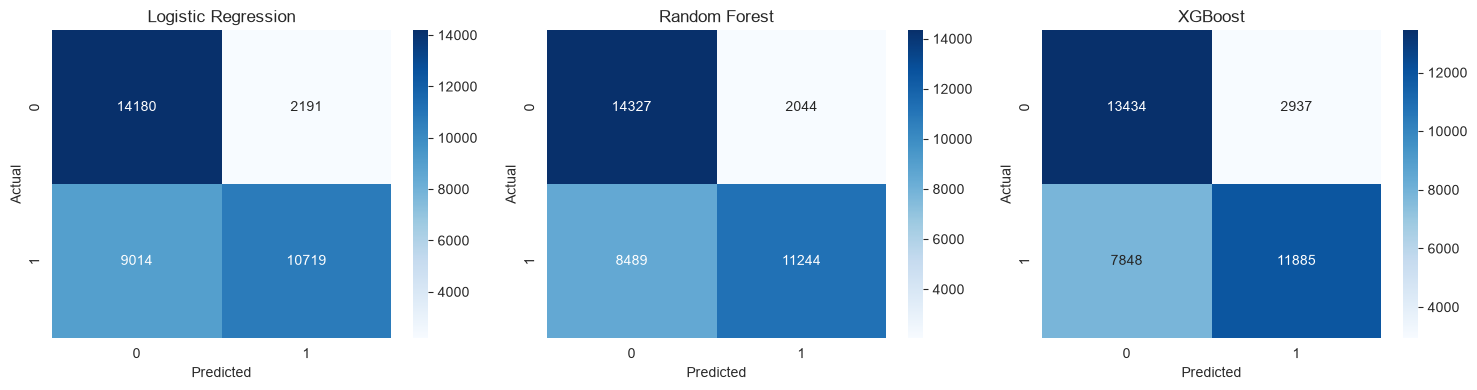

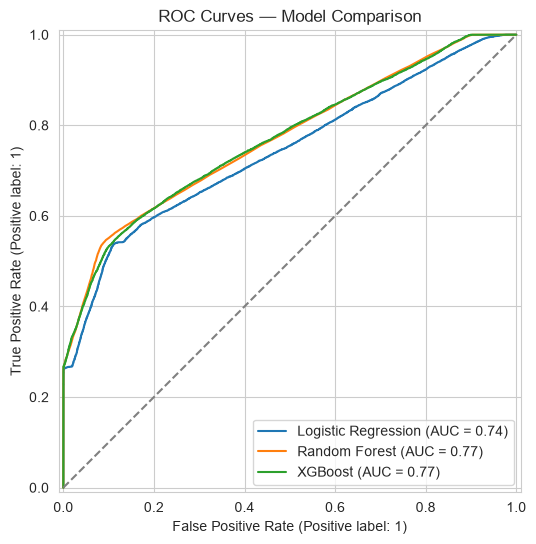

Best model: Random Forest
              precision    recall  f1-score   support

           0       0.63      0.88      0.73     16371
           1       0.85      0.57      0.68     19733

    accuracy                           0.71     36104
   macro avg       0.74      0.72      0.71     36104
weighted avg       0.75      0.71      0.70     36104



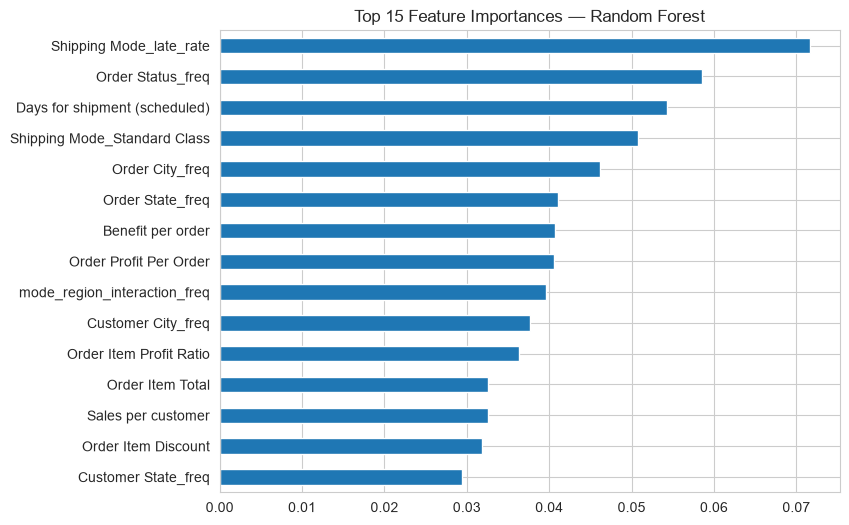

Models and Preprocessing Files Saved Successfully


In [1]:
# 1. Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# RobustScaler scales numbers using the median and IQR, so a few extreme outliers
# don't distort the whole column the way they would with a plain StandardScaler.
from sklearn.preprocessing import RobustScaler

# The three models we'll train and compare
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics used to judge how good each model is
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")  # keeps the notebook output clean of harmless warnings

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 2. Upload the Dataset

# This dataset is saved in "latin-1" encoding, not the usual "utf-8".
# Reading it as utf-8 throws an error, so we tell pandas which encoding to use.
df = pd.read_csv("../data/DataCoSupplyChainDataset.csv", encoding="latin-1")

print("Rows, Columns:", df.shape)
df.head()

# 3. Explore the Data (EDA)

# Shows column names, data types, and how many non-empty values each column has
df.info()

print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values per column (worst 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

# Our target column: 0 = delivered on time, 1 = delivered late.
# We check the split between the two so we know if the classes are balanced or not --
# this affects which metrics we should trust later (accuracy alone can be misleading
# if one class is much rarer than the other).
print(df["Late_delivery_risk"].value_counts(normalize=True))

sns.countplot(x="Late_delivery_risk", data=df)
plt.title("Late Delivery Risk — Class Balance (0 = On time, 1 = Late)")
plt.show()

sns.countplot(y="Delivery Status", data=df, order=df["Delivery Status"].value_counts().index)
plt.title("Delivery Status Breakdown")
plt.show()

# 4. Remove Columns We Shouldn't Use

# Three groups of columns get dropped here, each for a different reason:

# Leakage columns — these are only known AFTER a shipment has already happened (e.g. how many days shipping actually took). Using them would let the model "cheat" by peeking at the answer, so they must be removed.
# PII (personal info) — customer emails, names, passwords. Not useful for prediction, and shouldn't be used for privacy reasons.
# IDs and free text — order/customer/product ID numbers, text descriptions, image links. These are just labels, not real predictive signals.

leakage_cols = [
    "Days for shipping (real)",     # only known once shipping is done
    "Delivery Status",              # this basically states the outcome directly
    "shipping date (DateOrders)"    # only known once the order actually ships
]

pii_cols = [
    "Customer Email", "Customer Fname", "Customer Lname", "Customer Password",
    "Customer Street"
]

id_and_text_cols = [
    "Customer Id", "Order Customer Id", "Order Id", "Order Item Id",
    "Order Item Cardprod Id", "Product Card Id", "Product Category Id",
    "Product Description", "Product Image", "Product Name",
    "Customer Zipcode", "Order Zipcode", "Latitude", "Longitude",
    "Category Id", "Department Id"
]

drop_cols = leakage_cols + pii_cols + id_and_text_cols
drop_cols = [c for c in drop_cols if c in df.columns]  # only drop columns that actually exist

df_model = df.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns. Remaining shape:", df_model.shape)

# 5. Turn the Order Date Into Useful Features

df_model["order date (DateOrders)"] = pd.to_datetime(df_model["order date (DateOrders)"], errors="coerce")

df_model["order_dow"]        = df_model["order date (DateOrders)"].dt.dayofweek   # 0=Monday ... 6=Sunday
df_model["order_month"]      = df_model["order date (DateOrders)"].dt.month
df_model["order_is_weekend"] = df_model["order_dow"].isin([5, 6]).astype(int)      # 1 if Sat/Sun

# We still need the actual date column for the next step (splitting train/test by time),
# so we keep it around for now and will drop it right after the split.
df_model[["order date (DateOrders)", "order_dow", "order_month", "order_is_weekend"]].head()

# 6. Split Into Train and Test Sets — BEFORE Building Any More Features

# Sort so the earliest orders come first
df_model = df_model.sort_values("order date (DateOrders)").reset_index(drop=True)

split_point = int(len(df_model) * 0.8)   # 80% train, 20% test

train_df = df_model.iloc[:split_point].copy()
test_df  = df_model.iloc[split_point:].copy()

print("Training data covers:", train_df["order date (DateOrders)"].min(), "to", train_df["order date (DateOrders)"].max())
print("Test data covers:    ", test_df["order date (DateOrders)"].min(), "to", test_df["order date (DateOrders)"].max())
print("Train rows:", train_df.shape[0], " | Test rows:", test_df.shape[0])

# We only needed the raw date to do this split -- safe to drop it now from both sets
train_df = train_df.drop(columns=["order date (DateOrders)"])
test_df  = test_df.drop(columns=["order date (DateOrders)"])

# 7. Historical Late-Delivery Rate (calculated from TRAINING data only)

group_cols = ["Customer Segment", "Order Region", "Shipping Mode"]

# The overall late rate across all training data -- used as a fallback for any
# category that shows up in the test set but wasn't seen during training.
overall_late_rate = train_df["Late_delivery_risk"].mean()

historical_rate_maps = {}  # we'll save these later -- the API needs them too

for group_col in group_cols:
    # average late-delivery rate for each category, using TRAINING rows only
    rate_lookup = train_df.groupby(group_col)["Late_delivery_risk"].mean()
    historical_rate_maps[group_col] = rate_lookup

    # apply the same lookup table to both train and test
    train_df[f"{group_col}_late_rate"] = train_df[group_col].map(rate_lookup).fillna(overall_late_rate)
    test_df[f"{group_col}_late_rate"]  = test_df[group_col].map(rate_lookup).fillna(overall_late_rate)

train_df[[c + "_late_rate" for c in group_cols]].head()

# 8. Handle Outliers (extreme values)

outlier_cols = ["Sales", "Order Item Quantity", "Order Item Product Price", "Order Item Discount"]

outlier_bounds = {}  # save these too -- needed by the API later

for col in outlier_cols:
    lower_bound = train_df[col].quantile(0.01)
    upper_bound = train_df[col].quantile(0.99)
    outlier_bounds[col] = (lower_bound, upper_bound)

    train_df[col] = train_df[col].clip(lower_bound, upper_bound)
    test_df[col]  = test_df[col].clip(lower_bound, upper_bound)  # same boundary, applied to test

# Visual check: boxplots should now show far fewer extreme dots
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=train_df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 9. Feature Interaction

for dataset in (train_df, test_df):
    # combine shipping mode + region into one combined category
    dataset["mode_region_interaction"] = dataset["Shipping Mode"].astype(str) + "_" + dataset["Order Region"].astype(str)

    # quantity multiplied by discount rate -- captures "big discounted orders" as one signal
    dataset["qty_x_discount_rate"] = dataset["Order Item Quantity"] * dataset["Order Item Discount Rate"]

train_df[["mode_region_interaction", "qty_x_discount_rate"]].head()

# 10. Encode Categorical (text) Columns

low_cardinality_cols = ["Type", "Customer Segment", "Shipping Mode", "Market", "Order Region", "Category Name"]
low_cardinality_cols = [c for c in low_cardinality_cols if c in train_df.columns]

high_cardinality_cols = [
    "Customer City", "Customer Country", "Customer State",
    "Order City", "Order Country", "Order State",
    "Department Name", "mode_region_interaction", "Order Status"
]
high_cardinality_cols = [c for c in high_cardinality_cols if c in train_df.columns]

# --- Frequency encoding (learned from training data only) ---
frequency_maps = {}  # save these too -- needed by the API later

for col in high_cardinality_cols:
    freq_lookup = train_df[col].value_counts(normalize=True)  # e.g. "Colombo" -> 0.5
    frequency_maps[col] = freq_lookup

    train_df[col + "_freq"] = train_df[col].map(freq_lookup)
    test_df[col + "_freq"]  = test_df[col].map(freq_lookup).fillna(0)  # unseen category = 0

train_df = train_df.drop(columns=high_cardinality_cols)
test_df  = test_df.drop(columns=high_cardinality_cols)

# --- One-hot encoding (categories fixed from training data) ---
train_df = pd.get_dummies(train_df, columns=low_cardinality_cols, drop_first=True)
test_df  = pd.get_dummies(test_df, columns=low_cardinality_cols, drop_first=True)

# Make sure test has exactly the same columns as train, in the same order.
# (If a category only appears in test, this fills it with 0 -- since the model
# never learned about it during training, treating it as "none of the known categories" is correct.)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)

# 11. Scale the Numeric Columns

scale_cols = ["Sales", "Order Item Quantity", "Order Item Product Price",
              "Order Item Discount", "Order Item Discount Rate",
              "Sales per customer", "Order Item Total"]
scale_cols = [c for c in scale_cols if c in train_df.columns]

scaler = RobustScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])   # learn + apply on train
test_df[scale_cols]  = scaler.transform(test_df[scale_cols])        # apply the same rule to test

train_df[scale_cols].describe()

# Drop any text columns we missed, and fill any remaining empty cells with 0
# (a model can't handle text or empty values directly)
leftover_text_cols = train_df.select_dtypes(include="object").columns.tolist()
print("Dropping any leftover text columns:", leftover_text_cols)

train_df = train_df.drop(columns=leftover_text_cols)
test_df  = test_df.drop(columns=[c for c in leftover_text_cols if c in test_df.columns])

train_df = train_df.fillna(0)
test_df  = test_df.fillna(0)

print("Final train shape:", train_df.shape, "| Final test shape:", test_df.shape)

# 12. Separate Features (X) From the Target (y)

X_train = train_df.drop(columns=["Late_delivery_risk"])
y_train = train_df["Late_delivery_risk"]

X_test = test_df.drop(columns=["Late_delivery_risk"])
y_test = test_df["Late_delivery_risk"]

# Sanity check -- if these don't match, something went wrong with the encoding step above
assert list(X_train.columns) == list(X_test.columns), "Train and test columns don't match!"

print("X_train:", X_train.shape, " | X_test:", X_test.shape)
print("\nTrain target balance:\n", y_train.value_counts(normalize=True))
print("\nTest target balance:\n", y_test.value_counts(normalize=True))

# 13. Train and Compare Three Models

# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
#     "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False,
#                               eval_metric="logloss", random_state=42)
# }

# Calculate the exact ratio of On-Time (0) to Late (1) for XGBoost
class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()
xgb_scale_weight = class_0_count / class_1_count

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, 
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        random_state=42, 
        n_jobs=-1, 
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, 
        eval_metric="logloss", 
        random_state=42,
        scale_pos_weight=xgb_scale_weight
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    predictions   = model.predict(X_test)          # 0 or 1
    probabilities = model.predict_proba(X_test)[:, 1]  # probability of being "late" (class 1)

    results[name] = {
        "model": model,
        "accuracy":  accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall":    recall_score(y_test, predictions),
        "f1":        f1_score(y_test, predictions),
        "roc_auc":   roc_auc_score(y_test, probabilities),
        "preds": predictions,
        "probs": probabilities
    }

# Put just the metric numbers into a table for easy side-by-side comparison
results_table = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ["model", "preds", "probs"]}
    for name, r in results.items()
}).T

results_table

# Put just the metric numbers into a table for easy side-by-side comparison

results_table = pd.DataFrame({
    name: {
        k: v for k, v in r.items()
        if k not in ["model", "preds", "probs"]
    }
    for name, r in results.items()
}).T

# ---------------------------------------------------------
# Display performance of ALL models BEFORE selecting the best
# ---------------------------------------------------------

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(results_table.round(4))

print("\n" + "=" * 80)
print("MODEL PERFORMANCE (%)")
print("=" * 80)

print((results_table * 100).round(2))

# 14. Compare the Models Visually

results_table[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

# Confusion matrix for each model: shows correct vs incorrect predictions, split by class
fig, axes = plt.subplots(1, len(models), figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve: the closer a line hugs the top-left corner, the better that model is
# at telling risky and non-risky shipments apart
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    RocCurveDisplay.from_predictions(y_test, r["probs"], name=name, ax=ax)
plt.title("ROC Curves — Model Comparison")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # a random-guess baseline for reference
plt.show()

# Pick the model with the best ROC-AUC score as our final model
best_model_name = results_table["roc_auc"].astype(float).idxmax()
best_model = results[best_model_name]["model"]

print("Best model:", best_model_name)
print(classification_report(y_test, results[best_model_name]["preds"]))

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("The selected model doesn't expose feature importances (this is normal for Logistic Regression).")

# 15. Save Everything the API Will Need

joblib.dump(best_model, '../../optichain-backend/model/late_delivery_model.pkl')
joblib.dump(scaler, '../../optichain-backend/model/scaler.pkl')
joblib.dump(list(X_train.columns), '../../optichain-backend/model/model_columns.pkl')
joblib.dump(historical_rate_maps, '../../optichain-backend/model/historical_rate_maps.pkl')
joblib.dump(frequency_maps, '../../optichain-backend/model/frequency_maps.pkl')
joblib.dump(overall_late_rate, '../../optichain-backend/model/overall_late_rate.pkl')
joblib.dump(outlier_bounds, '../../optichain-backend/model/outlier_bounds.pkl')

print("Models and Preprocessing Files Saved Successfully")
